# NLP Analysis — Egypt Real Estate Descriptions

In this notebook we read the property descriptions and try to understand what they say.

We will do 5 things:
1. Find out which descriptions are English and which are Arabic
2. Clean the English text so it is easier to work with
3. Find the most common words (TF-IDF)
4. Group descriptions into topics (LDA)
5. Check if a description sounds positive or negative (VADER)

**Input file:** `egypt_re_clean.csv`  
**Output file:** `egypt_re_nlp.csv`

## Step 0 — Install packages

Run this once if any package is missing. It is commented out by default.

In [4]:
# Uncomment and run this block ONCE if you get an import error below
# import subprocess, sys
# packages = [
#     "langdetect", "nltk", "vaderSentiment",
#     "wordcloud", "scikit-learn",
#     "matplotlib", "seaborn", "pandas", "numpy",
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
# print("Done installing.")

## Step 1 — Import libraries

We load everything we need at the top so we don't have to import things later.

In [5]:
import warnings
warnings.filterwarnings("ignore")  # hide unimportant warning messages

import re           # for removing patterns from text (like numbers)
import string       # gives us a list of punctuation characters
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK is a popular library for working with text
import nltk
from nltk.corpus import stopwords        # common words like 'the', 'and'
from nltk.stem import WordNetLemmatizer  # turns 'running' -> 'run'
from nltk.tokenize import word_tokenize  # splits text into a list of words

# langdetect guesses what language a text is written in
from langdetect import detect, LangDetectException

# WordCloud draws a picture of the most common words
from wordcloud import WordCloud

# scikit-learn tools for text and topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# VADER gives each text a score: positive, neutral, or negative
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download the NLTK data files we need
for item in ["stopwords", "punkt", "wordnet", "omw-1.4", "punkt_tab", "averaged_perceptron_tagger"]:
    nltk.download(item, quiet=True)

# Set a clean look for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Create a folder to save chart images
os.makedirs("nlp_outputs", exist_ok=True)

print("All imports done.")

All imports done.


## Step 2 — Load the data

We read the cleaned CSV file that was saved in the previous notebook.

In [6]:
# Change this path to wherever you saved egypt_re_clean.csv
DATA_PATH = r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_clean.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(f"Missing descriptions: {df['description'].isna().sum()}")

# Show a few columns to check the data looks right
df[["listing_id", "offering_type", "city", "description", "price_per_sqm"]].head(3)

Rows: 36870   Columns: 70
Missing descriptions: 0


,listing_id,offering_type,city,description,price_per_sqm
0,HYEPN5XPWQT7K05K4ST7EDWW5R,Rent,Cairo,Unit Description: Location: Villette Compound ...,520.833333
1,9Q295E8B6ET3V30Z31925BR6ZG,Rent,Giza,For Rent – Premium 196m² Fully Finished Apartm...,255.102041
2,R9PTSC3V5RZ77ZT9X69TBE1PEC,Rent,Giza,Furnished villa for rent at a special price To...,375.000000


## Step 3 — Detect the language of each description

`langdetect` looks at the text and returns a short code like `'en'` for English or `'ar'` for Arabic.

If the text is too short to guess, we just call it `'unknown'`.

In [7]:
def detect_lang(text):
    # Return 'unknown' if text is missing or very short
    if not isinstance(text, str) or len(text.strip()) < 20:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

print("Detecting language for each row... (this takes a moment)")
df["lang"] = df["description"].apply(detect_lang)

print("\nHow many rows per language:")
print(df["lang"].value_counts().head(10))

Detecting language for each row... (this takes a moment)

How many rows per language:
lang
en         35346
ar          1512
fr             2
unknown        2
de             2
cy             1
nl             1
da             1
it             1
sk             1
Name: count, dtype: int64


English : 35,346  (95.9%)
Arabic  : 1,512  (4.1%)
Other   : 12


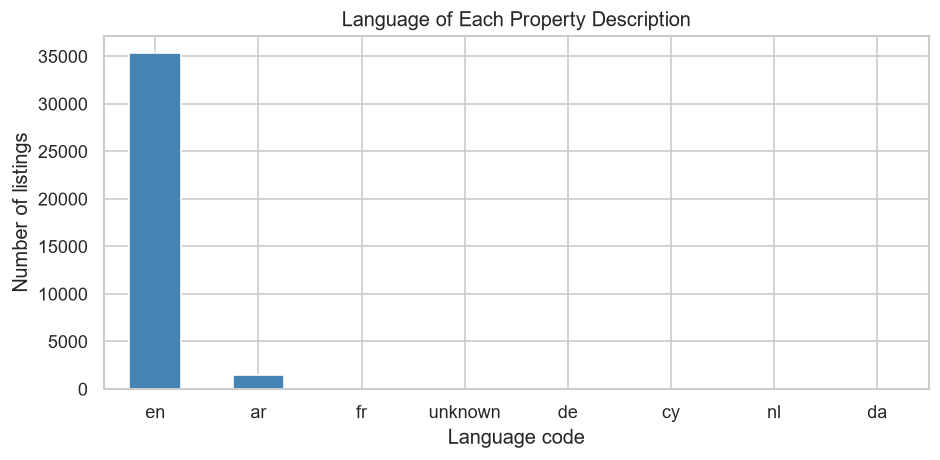

In [8]:
# Split the data into English and Arabic groups
df_en = df[df["lang"] == "en"].copy()   # English only
df_ar = df[df["lang"] == "ar"].copy()   # Arabic only

total = len(df)
print(f"English : {len(df_en):,}  ({len(df_en)/total*100:.1f}%)")
print(f"Arabic  : {len(df_ar):,}  ({len(df_ar)/total*100:.1f}%)")
print(f"Other   : {total - len(df_en) - len(df_ar):,}")

# Bar chart of language counts
fig, ax = plt.subplots(figsize=(8, 4))
df["lang"].value_counts().head(8).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Language of Each Property Description")
ax.set_xlabel("Language code")
ax.set_ylabel("Number of listings")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("nlp_outputs/01_language_counts.png")
plt.show()

## Step 4 — Clean the English descriptions

Raw text has a lot of noise: numbers, punctuation, and very common words like "the" or "and".
We remove all of that so only the meaningful words are left.

We also apply **lemmatization** — this converts words to their base form so "rooms" and "room" are treated as the same word.

In [9]:
# Set up our tools
lemmatizer = WordNetLemmatizer()

# Standard English stop words ('the', 'is', 'in', ...)
base_stopwords = set(stopwords.words("english"))

# Extra words that are too common in real-estate listings to be useful
extra_stopwords = {
    "property", "apartment", "unit", "floor", "building",
    "area", "sqm", "meter", "square", "located", "location",
    "available", "contact", "call", "price", "offer", "egp",
    "cairo", "egypt", "giza", "compound", "new", "one", "two",
    "three", "four", "five", "also", "get", "great", "good"
}

all_stopwords = base_stopwords | extra_stopwords  # combine both sets


def clean_text(text):
    """Take raw text and return only the important words."""
    if not isinstance(text, str):
        return ""

    # Remove any HTML tags (like <br>)
    text = re.sub(r"<[^>]+>", " ", text)

    # Make everything lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation (. , ! ? etc.)
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Split into individual words
    tokens = word_tokenize(text)

    # Keep only words that are not stop words and longer than 2 characters
    # Also convert each word to its base form (e.g. 'bedrooms' -> 'bedroom')
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in all_stopwords and len(word) > 2
    ]

    return " ".join(clean_tokens)


print("Cleaning text...")
df_en["description_clean"] = df_en["description"].apply(clean_text)

# Drop rows where the cleaned text ended up too short to be useful
df_en_valid = df_en[df_en["description_clean"].str.len() >= 20].copy()

print(f"Rows kept after cleaning: {len(df_en_valid):,} / {len(df_en):,}")

# Show a before/after example
print("\n--- Before cleaning ---")
print(df_en["description"].iloc[0][:200])
print("\n--- After cleaning ---")
print(df_en_valid["description_clean"].iloc[0][:200])

Cleaning text...
Rows kept after cleaning: 35,346 / 35,346

--- Before cleaning ---
Unit Description: Location: Villette Compound - Sodic - Fifth Settlement Area: 142 sq m Unit Layout: 2 bedrooms + 2 bathrooms + reception + kitchen The unit is fully furnished and equipped Price: 75,0

--- After cleaning ---
description villette sodic fifth settlement layout bedroom bathroom reception kitchen fully furnished equipped annually guarantee save time fulfill request best lowest possible goal build largest cust


### 4.1 — Most common words (top 30)

We count how many times each word appears across all descriptions and plot the top 30.

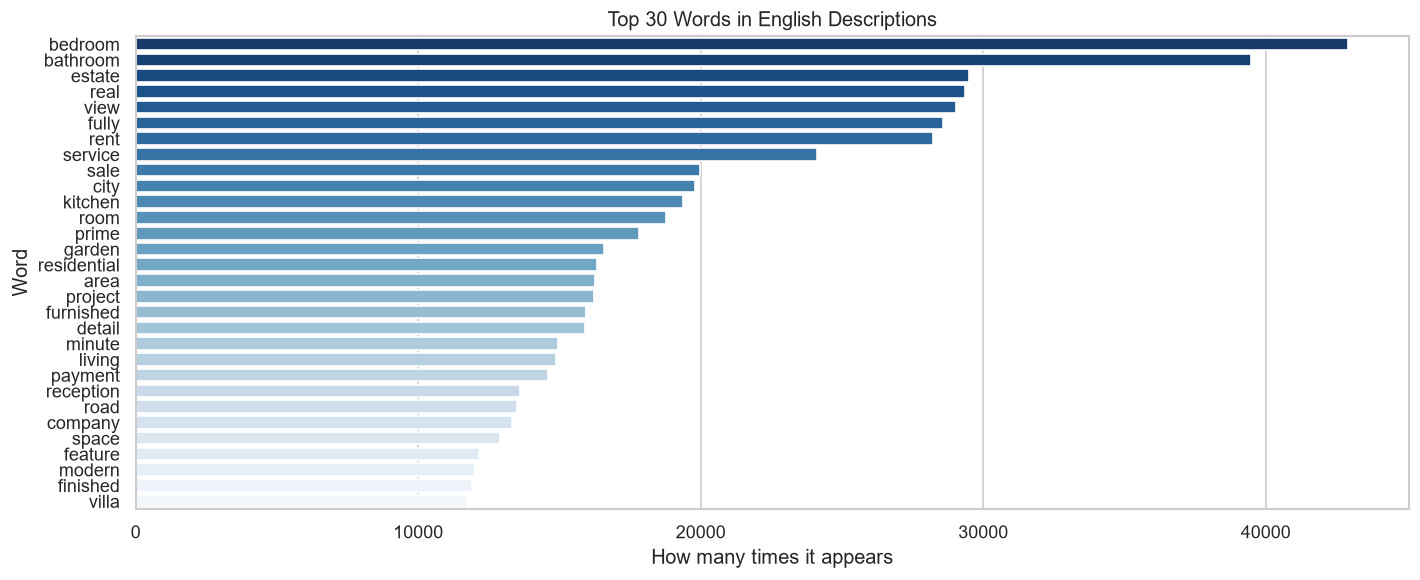

       word  count
    bedroom  42917
   bathroom  39462
     estate  29501
       real  29362
       view  29019
      fully  28583
       rent  28219
    service  24117
       sale  19981
       city  19814
    kitchen  19379
       room  18788
      prime  17802
     garden  16562
residential  16324
       area  16274
    project  16227
  furnished  15942
     detail  15919
     minute  14948
     living  14866
    payment  14578
  reception  13589
       road  13479
    company  13324
      space  12898
    feature  12147
     modern  11996
   finished  11918
      villa  11710


In [10]:
from collections import Counter

# Join all cleaned descriptions into one big string, then split into words
all_words = " ".join(df_en_valid["description_clean"]).split()

# Count how many times each word appears
word_counts = Counter(all_words)

# Get the 30 most common words and put them in a table
top30 = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top30, x="count", y="word", ax=ax, palette="Blues_r")
ax.set_title("Top 30 Words in English Descriptions")
ax.set_xlabel("How many times it appears")
ax.set_ylabel("Word")
plt.tight_layout()
plt.savefig("nlp_outputs/02_top30_words.png")
plt.show()

print(top30.to_string(index=False))

### 4.2 — TF-IDF (which words are most important?)

Word frequency just counts how often a word appears. But some words appear everywhere and are not really useful.

**TF-IDF** (Term Frequency – Inverse Document Frequency) gives higher scores to words that appear a lot in one listing but not in all listings. Those words tell us something *specific* about that listing.

In [11]:
tfidf = TfidfVectorizer(
    max_features=500,   # keep only the top 500 words/phrases
    min_df=5,           # ignore words that appear in fewer than 5 listings
    max_df=0.85,        # ignore words that appear in more than 85% of listings
    ngram_range=(1, 2)  # look at single words AND pairs of words (e.g. 'sea view')
)

# Fit the vectorizer and convert text to numbers
tfidf_matrix = tfidf.fit_transform(df_en_valid["description_clean"])

print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")
print(f"  -> {tfidf_matrix.shape[0]} listings x {tfidf_matrix.shape[1]} words/phrases")

# Find which words have the highest average TF-IDF score
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
top_words = tfidf_df.mean().sort_values(ascending=False).head(20)

print("\nTop 20 most important words by TF-IDF score:")
print(top_words)

Shape of TF-IDF matrix: (35346, 500)
  -> 35346 listings x 500 words/phrases

Top 20 most important words by TF-IDF score:
estate              0.051486
real                0.051375
real estate         0.050971
rent                0.049525
view                0.047980
fully               0.047820
room                0.040320
bedroom bathroom    0.037310
city                0.037077
service             0.036893
garden              0.036631
kitchen             0.036504
furnished           0.036452
sale                0.036425
payment             0.034804
prime               0.033722
detail              0.032659
minute              0.032351
living              0.030320
project             0.030200
dtype: float64


### 4.3 — Word clouds for Buy vs Rent

A word cloud is a picture where bigger words appear more often. We make one for Buy listings and one for Rent listings to see if they use different words.

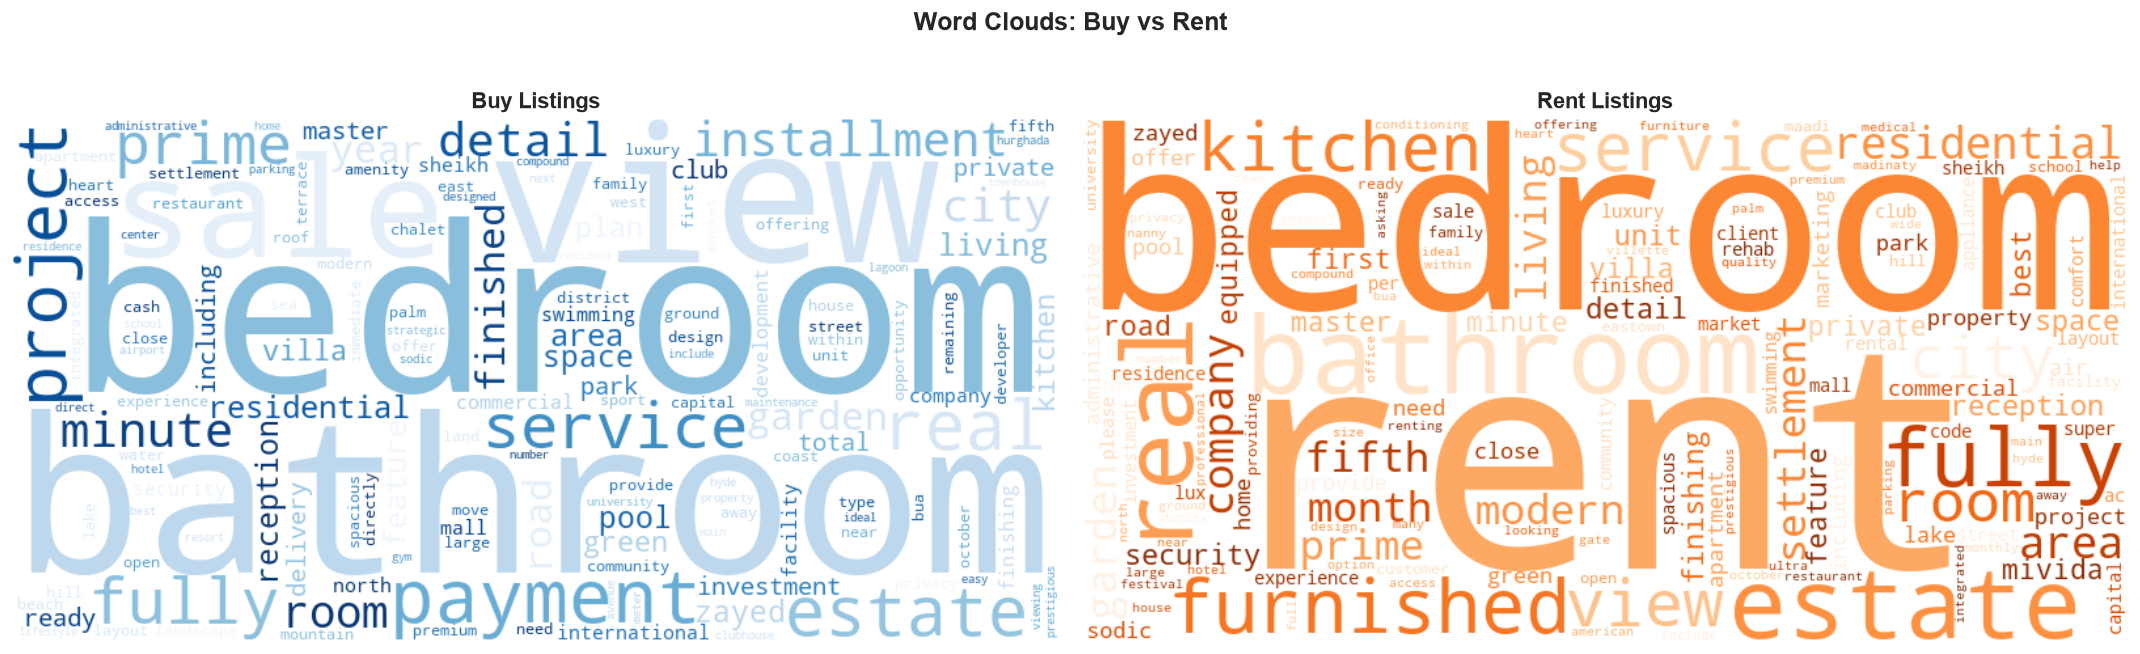

Buy listings : 17,175
Rent listings: 18,171


In [12]:
def make_wordcloud(text_series, title, colormap, ax):
    """Draw a word cloud on a given matplotlib axis."""
    # Join all descriptions into one big text
    all_text = " ".join(text_series.dropna())

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=150,
        collocations=False  # don't repeat word pairs
    ).generate(all_text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")  # hide the x and y axes
    ax.set_title(title, fontsize=13, fontweight="bold")


# Filter by offering type
buy_text  = df_en_valid[df_en_valid["offering_type"] == "Buy"]["description_clean"]
rent_text = df_en_valid[df_en_valid["offering_type"] == "Rent"]["description_clean"]

# Draw side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
make_wordcloud(buy_text,  "Buy Listings",  colormap="Blues",   ax=axes[0])
make_wordcloud(rent_text, "Rent Listings", colormap="Oranges", ax=axes[1])

plt.suptitle("Word Clouds: Buy vs Rent", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("nlp_outputs/03_wordclouds_buy_vs_rent.png", bbox_inches="tight")
plt.show()

print(f"Buy listings : {len(buy_text):,}")
print(f"Rent listings: {len(rent_text):,}")

## Step 5 — Topic Modeling with LDA

LDA (Latent Dirichlet Allocation) reads all the descriptions and tries to find groups of listings that talk about similar things.

We tell it to find 5 topics. It then shows us the most common words in each topic. We look at those words and decide a good name for the topic ourselves.

> Note: LDA works better with raw word counts, not TF-IDF scores, so we use `CountVectorizer` here.

In [13]:
# Convert text to a matrix of raw word counts
count_vec = CountVectorizer(
    max_features=2000,  # top 2000 words
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 1)  # single words only (LDA works best this way)
)
count_matrix = count_vec.fit_transform(df_en_valid["description_clean"])
print(f"Count matrix shape: {count_matrix.shape}")

# Train the LDA model with 5 topics
N_TOPICS = 5
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=15,
    learning_method="online",
    random_state=42
)
lda.fit(count_matrix)
print("LDA training done.")

Count matrix shape: (35346, 2000)
LDA training done.


In [14]:
# Print the top words for each topic so we can read and label them
feature_names = count_vec.get_feature_names_out()
N_TOP_WORDS = 12

topic_top_words = {}  # we'll store these to use in the next cell

print(f"Top {N_TOP_WORDS} words per topic:")
print("-" * 50)
for topic_idx, topic in enumerate(lda.components_):
    # Get the indices of the top words (sorted highest to lowest)
    top_indices = topic.argsort()[:-N_TOP_WORDS - 1:-1]
    top_words = [feature_names[i] for i in top_indices]
    topic_top_words[topic_idx] = top_words
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

Top 12 words per topic:
--------------------------------------------------
Topic 0: view, fully, room, payment, detail, kitchen, zayed, reception, prime, garden, installment, sheikh
Topic 1: estate, real, company, need, residential, service, commercial, marketing, investment, experience, market, administrative
Topic 2: minute, service, road, project, city, area, green, space, residential, security, pool, feature
Topic 3: rent, settlement, fifth, furnished, fully, view, sale, mivida, street, kitchen, month, lake
Topic 4: sale, sea, coast, north, beach, chalet, project, view, hurghada, resort, home, property


### 5.1 — Label each topic

Look at the words above and decide what each topic is about. Update the `TOPIC_LABELS` dictionary below.

In [15]:
# Change these labels after reading the top words above
TOPIC_LABELS = {
    0: "Property Sales & Luxury Communities",
    1: "Modern Residential Communities",
    2: "Real Estate Business & Investment",
    3: "Furnished Rental Properties",
    4: "Location, Amenities & Accessibility",
}

# Print to confirm
for k, label in TOPIC_LABELS.items():
    print(f"Topic {k}: {label}")
    print(f"  Top words: {', '.join(topic_top_words[k][:8])}")

Topic 0: Property Sales & Luxury Communities
  Top words: view, fully, room, payment, detail, kitchen, zayed, reception
Topic 1: Modern Residential Communities
  Top words: estate, real, company, need, residential, service, commercial, marketing
Topic 2: Real Estate Business & Investment
  Top words: minute, service, road, project, city, area, green, space
Topic 3: Furnished Rental Properties
  Top words: rent, settlement, fifth, furnished, fully, view, sale, mivida
Topic 4: Location, Amenities & Accessibility
  Top words: sale, sea, coast, north, beach, chalet, project, view


In [16]:
# Score every listing: how much does it belong to each topic?
doc_topic_scores = lda.transform(count_matrix)  # shape: (num_listings, num_topics)

# Pick the topic with the highest score for each listing
df_en_valid["topic_id"]         = doc_topic_scores.argmax(axis=1)
df_en_valid["topic_label"]      = df_en_valid["topic_id"].map(TOPIC_LABELS)
df_en_valid["topic_confidence"] = doc_topic_scores.max(axis=1)  # the score of the winning topic

print("How many listings per topic:")
print(df_en_valid["topic_label"].value_counts())

How many listings per topic:
topic_label
Property Sales & Luxury Communities    12475
Real Estate Business & Investment      10957
Modern Residential Communities          6085
Furnished Rental Properties             3083
Location, Amenities & Accessibility     2746
Name: count, dtype: int64


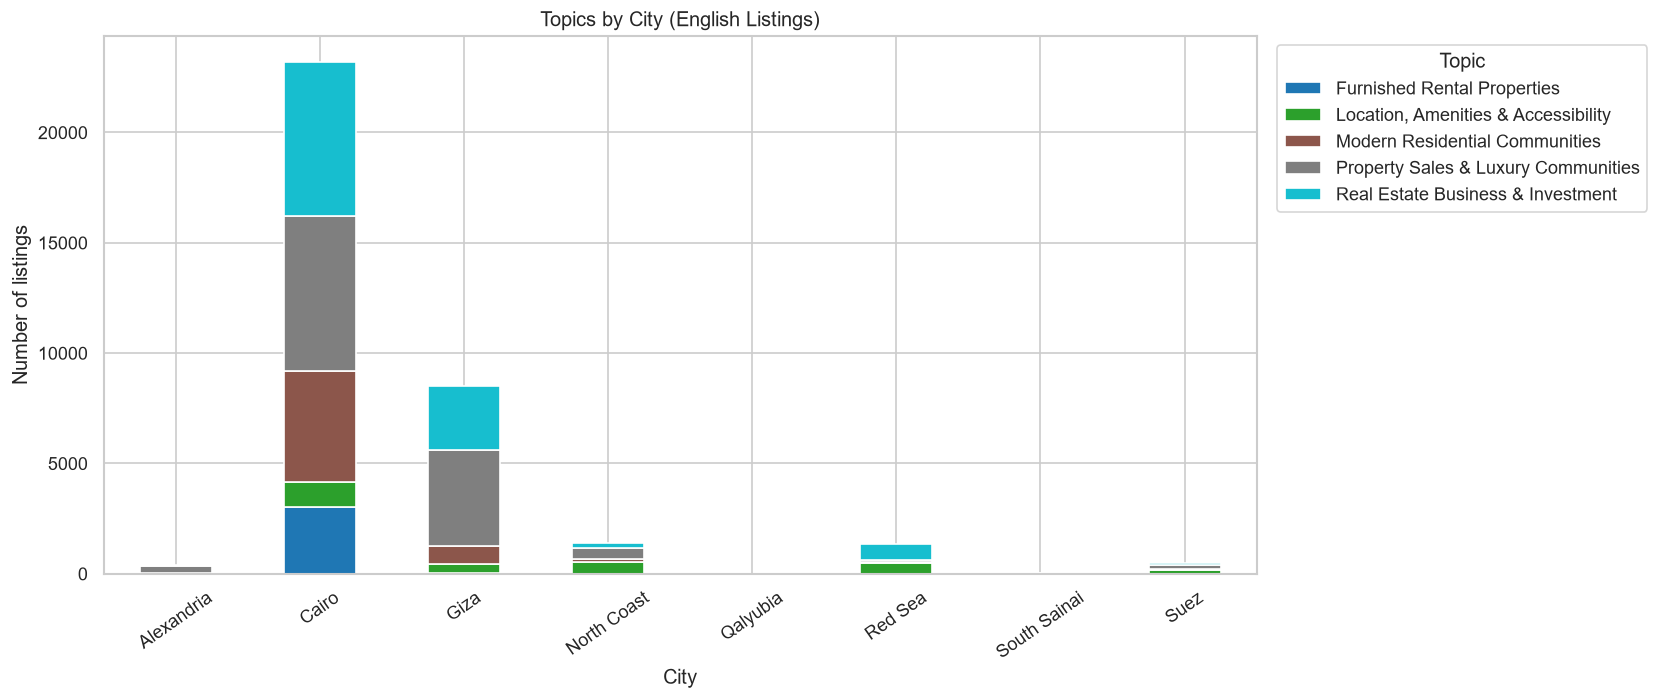

In [17]:
# Stacked bar chart: which topics appear in which cities?
topic_by_city = (
    df_en_valid.groupby(["city", "topic_label"])
    .size()
    .reset_index(name="count")
)

# Only show the 8 cities with the most listings
top_cities = df_en_valid["city"].value_counts().head(8).index.tolist()
topic_by_city = topic_by_city[topic_by_city["city"].isin(top_cities)]

# Pivot so cities are rows and topics are columns
pivot = topic_by_city.pivot(index="city", columns="topic_label", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="white")
ax.set_title("Topics by City (English Listings)")
ax.set_xlabel("City")
ax.set_ylabel("Number of listings")
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig("nlp_outputs/04_topics_by_city.png", bbox_inches="tight")
plt.show()

## Step 6 — Sentiment Analysis with VADER

VADER reads a piece of text and gives it a score:
- Score > 0.05 → **Positive**
- Score < -0.05 → **Negative**
- Anything in between → **Neutral**

We use the **original** text here (not the cleaned one) because VADER uses capital letters and punctuation as clues.

In [18]:
vader = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    """Return the compound sentiment score (-1 to +1)."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    return vader.polarity_scores(text)["compound"]

def score_to_label(score):
    """Convert a number score to a word label."""
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    return "Neutral"

print("Scoring sentiment for each listing...")
df_en_valid["sentiment_score"] = df_en_valid["description"].apply(get_sentiment_score)
df_en_valid["sentiment_label"] = df_en_valid["sentiment_score"].apply(score_to_label)

print("\nSentiment counts:")
print(df_en_valid["sentiment_label"].value_counts())
print(f"\nAverage sentiment score: {df_en_valid['sentiment_score'].mean():.4f}")

Scoring sentiment for each listing...

Sentiment counts:
sentiment_label
Positive    32187
Neutral      2701
Negative      458
Name: count, dtype: int64

Average sentiment score: 0.7433


### 6.1 — Does a more positive description mean a higher price?

Let's check if listings with positive descriptions cost more per square meter.

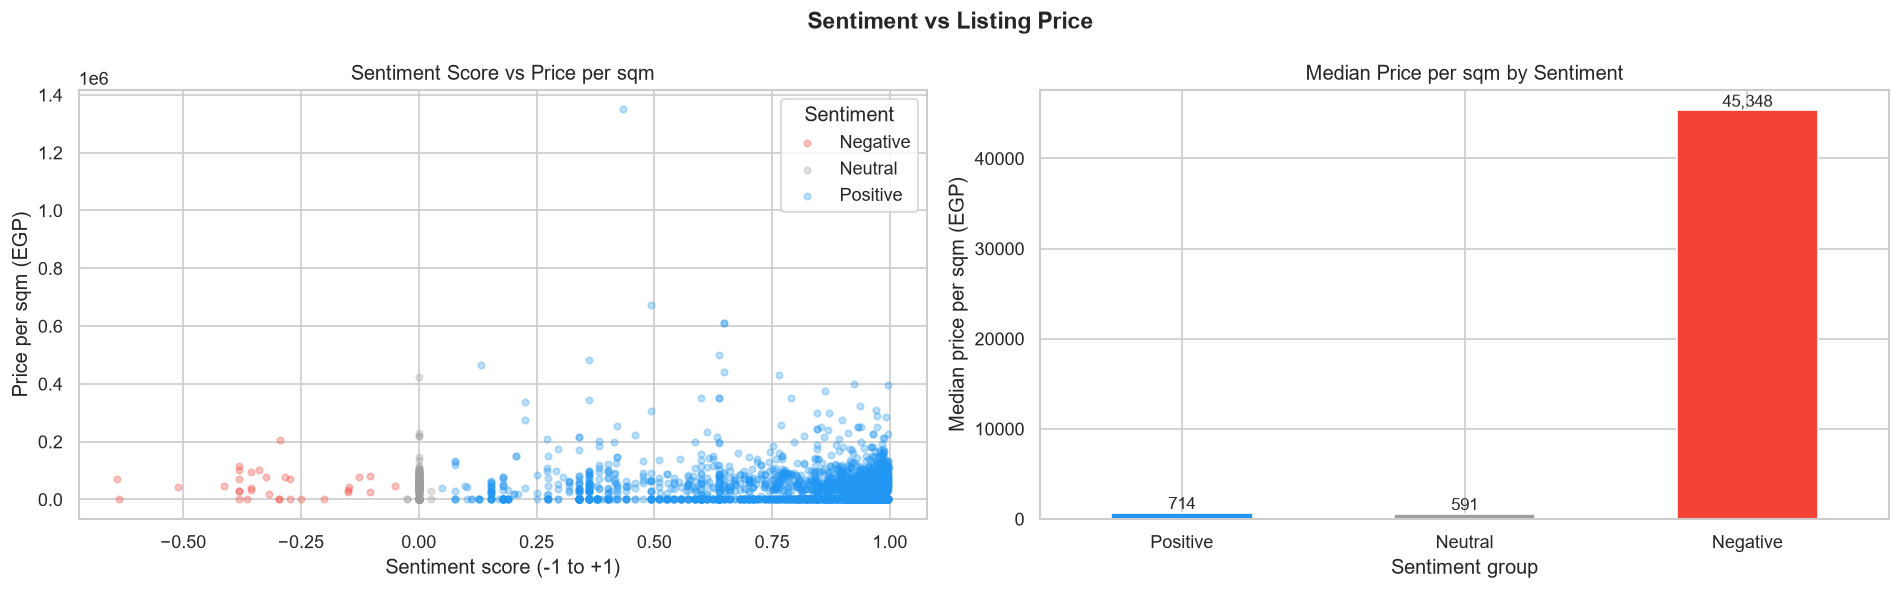

Correlation between sentiment and price: -0.0201


In [19]:
# Colors: blue = positive, grey = neutral, red = negative
color_map = {"Positive": "#2196F3", "Neutral": "#9E9E9E", "Negative": "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left chart: scatter plot ---
ax = axes[0]

# Take a random sample so the chart is not too crowded
sample = df_en_valid.dropna(subset=["price_per_sqm", "sentiment_score"]).sample(
    min(3000, len(df_en_valid)), random_state=42
)

for label, group in sample.groupby("sentiment_label"):
    ax.scatter(
        group["sentiment_score"],
        group["price_per_sqm"],
        alpha=0.3, s=15,
        color=color_map[label],
        label=label
    )

ax.set_xlabel("Sentiment score (-1 to +1)")
ax.set_ylabel("Price per sqm (EGP)")
ax.set_title("Sentiment Score vs Price per sqm")
ax.legend(title="Sentiment")

# --- Right chart: median price per sentiment group ---
ax2 = axes[1]
median_prices = (
    df_en_valid.groupby("sentiment_label")["price_per_sqm"]
    .median()
    .reindex(["Positive", "Neutral", "Negative"])
)
median_prices.plot(kind="bar", ax=ax2, color=["#2196F3", "#9E9E9E", "#F44336"], edgecolor="white")
ax2.set_title("Median Price per sqm by Sentiment")
ax2.set_xlabel("Sentiment group")
ax2.set_ylabel("Median price per sqm (EGP)")
ax2.tick_params(axis="x", rotation=0)

# Add the number on top of each bar
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():,.0f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=10
    )

plt.suptitle("Sentiment vs Listing Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("nlp_outputs/05_sentiment_vs_price.png", bbox_inches="tight")
plt.show()

# Check the correlation (0 = no link, 1 = strong link)
corr = df_en_valid[["sentiment_score", "price_per_sqm"]].dropna().corr().iloc[0, 1]
print(f"Correlation between sentiment and price: {corr:.4f}")

### 6.2 — Boxplot: Price spread by sentiment group

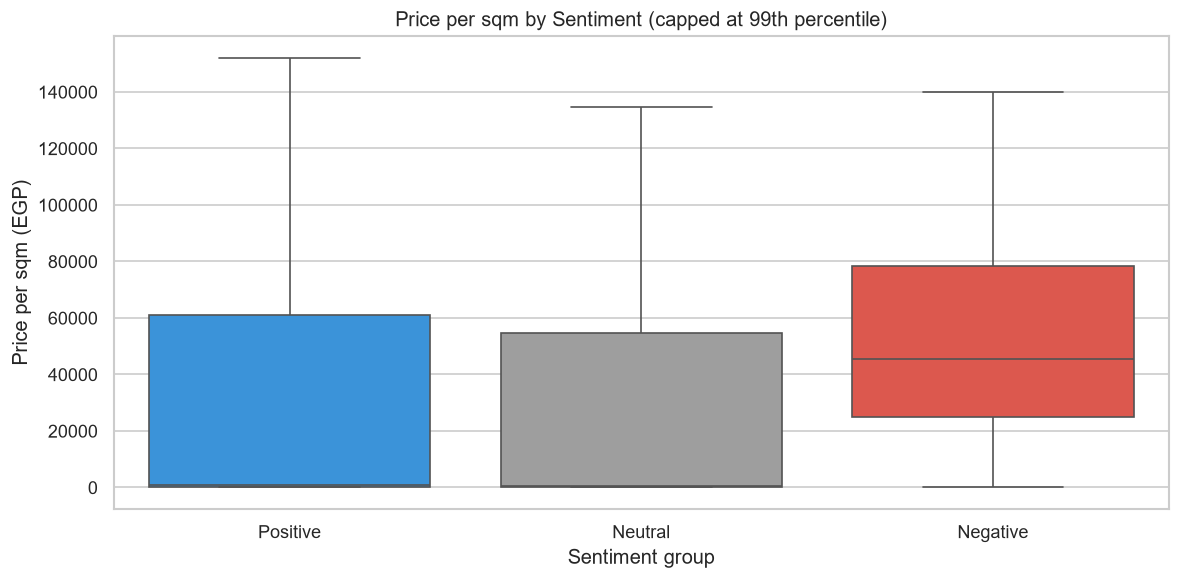

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = df_en_valid.dropna(subset=["price_per_sqm", "sentiment_label"]).copy()

# Cap very high prices so the chart is not squeezed
cap = plot_data["price_per_sqm"].quantile(0.99)
plot_data["price_capped"] = plot_data["price_per_sqm"].clip(upper=cap)

sns.boxplot(
    data=plot_data,
    x="sentiment_label",
    y="price_capped",
    order=["Positive", "Neutral", "Negative"],
    palette=color_map,
    ax=ax,
    showfliers=False  # hide individual dots above the whiskers
)

ax.set_title("Price per sqm by Sentiment (capped at 99th percentile)")
ax.set_xlabel("Sentiment group")
ax.set_ylabel("Price per sqm (EGP)")
plt.tight_layout()
plt.savefig("nlp_outputs/06_boxplot_price_by_sentiment.png")
plt.show()

## Step 7 — Add NLP columns back to the full dataset

So far we only have NLP results for English listings.
We merge those results back onto the full dataframe and fill in default values for non-English rows.

In [21]:
# Grab only the new NLP columns from the English listings
nlp_cols = df_en_valid[[
    "listing_id", "lang", "topic_id", "topic_label",
    "topic_confidence", "sentiment_score", "sentiment_label",
    "description_clean"
]].copy()

# Merge onto the full dataframe using listing_id as the key
df_nlp = df.merge(nlp_cols, on="listing_id", how="left")

# Fix any duplicate lang columns created by the merge
if "lang_x" in df_nlp.columns:
    df_nlp["lang"] = df_nlp["lang_x"].combine_first(df_nlp["lang_y"])
    df_nlp.drop(columns=[c for c in df_nlp.columns if c in ["lang_x", "lang_y"]], inplace=True)

# For non-English rows that have no NLP result, fill with sensible defaults
df_nlp["topic_label"].fillna("Non-English", inplace=True)
df_nlp["sentiment_score"].fillna(0.0, inplace=True)   # treat as neutral
df_nlp["sentiment_label"].fillna("Neutral", inplace=True)
df_nlp["description_clean"].fillna("", inplace=True)

print(f"Final dataset shape: {df_nlp.shape}")
print("\nTopic breakdown:")
print(df_nlp["topic_label"].value_counts())
print("\nSentiment breakdown:")
print(df_nlp["sentiment_label"].value_counts())

Final dataset shape: (36870, 77)

Topic breakdown:
topic_label
Property Sales & Luxury Communities    12475
Real Estate Business & Investment      10957
Modern Residential Communities          6085
Furnished Rental Properties             3083
Location, Amenities & Accessibility     2746
Name: count, dtype: int64

Sentiment breakdown:
sentiment_label
Positive    32187
Neutral      2701
Negative      458
Name: count, dtype: int64


## Step 8 — Save the output

We save the full dataset with the new NLP columns to a CSV file.

In [22]:
# Change this path to where you want to save the file
OUTPUT_PATH = "egypt_re_nlp.csv"

df_nlp.to_csv(OUTPUT_PATH, index=False)

print(f"Saved to: {OUTPUT_PATH}")
print(f"Rows: {len(df_nlp):,}   Columns: {df_nlp.shape[1]}")

# Confirm the new columns are in the file
new_cols = ["lang", "topic_label", "topic_id", "topic_confidence",
            "sentiment_score", "sentiment_label", "description_clean"]
found = [c for c in new_cols if c in df_nlp.columns]
print(f"New columns added: {found}")

Saved to: egypt_re_nlp.csv
Rows: 36,870   Columns: 77
New columns added: ['lang', 'topic_label', 'topic_id', 'topic_confidence', 'sentiment_score', 'sentiment_label', 'description_clean']


## Step 9 — Summary

A quick printout of what we did and what we found.

In [23]:
print("=" * 50)
print("NLP ANALYSIS — SUMMARY")
print("=" * 50)
print(f"Total listings        : {len(df):,}")
print(f"English descriptions  : {len(df_en):,}")
print(f"Arabic descriptions   : {len(df_ar):,}")
print(f"Other / Unknown       : {len(df) - len(df_en) - len(df_ar):,}")
print(f"Valid EN for NLP      : {len(df_en_valid):,}")
print(f"TF-IDF features       : {tfidf_matrix.shape[1]}")
print(f"LDA topics            : {N_TOPICS}")
print(f"Avg sentiment score   : {df_nlp['sentiment_score'].mean():.4f}")
print(f"Output saved to       : egypt_re_nlp.csv")
print(f"Charts saved to       : nlp_outputs/")
print("=" * 50)
print("\nNext: open 04_ml_prediction.ipynb")

NLP ANALYSIS — SUMMARY
Total listings        : 36,870
English descriptions  : 35,346
Arabic descriptions   : 1,512
Other / Unknown       : 12
Valid EN for NLP      : 35,346
TF-IDF features       : 500
LDA topics            : 5
Avg sentiment score   : 0.7433
Output saved to       : egypt_re_nlp.csv
Charts saved to       : nlp_outputs/

Next: open 04_ml_prediction.ipynb
